# NB05 — Lanmodulin clade restriction (H3)

**Project**: lanthanide_methylotrophy_atlas
**Goal**: Test H3 — *Bakta-validated lanmodulin hits are restricted to specific α-Proteobacterial methylotroph clades (Beijerinckiaceae, Acetobacteraceae, Hyphomicrobiaceae) and co-occur with xoxF in ≥80% of cases.*

**Inputs** (cached, no Spark required):
- `data/genome_marker_matrix.csv` — NB01 marker matrix
- `data/bakta_lanmodulin_validated_taxa.csv` — NB01 species table for the 62 bakta-validated lanmodulin genomes
- `data/marker_taxonomy_rollup_genus.csv` — NB02 genus rollup

**Outputs**:
- `data/h3_lanmodulin_clade_restriction.csv`
- `data/h3_lanmodulin_xoxF_cooccurrence.csv`
- `figures/h3_lanmodulin_clade_restriction.png`

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import binomtest

DATA = Path("../data")
FIG = Path("../figures")


## 1. Load lanmodulin-bearing genome inventory + taxonomy

In [2]:
matrix = pd.read_csv(DATA / "genome_marker_matrix.csv")
lanm_genomes = matrix[matrix["lanM_bakta"] == 1].copy()
print(f"Bakta-validated lanmodulin genomes: {len(lanm_genomes)}")

# Co-occurrence with xoxF (using either-source view, since xoxF eggNOG vs bakta capture different subsets)
lanm_genomes["any_xoxF"] = lanm_genomes["xoxF_either"]
lanm_genomes["full_cassette_relaxed"] = (
    (lanm_genomes["xoxF_either"] == 1)
    & (lanm_genomes["xoxJ_bakta"] == 1)
    & (lanm_genomes[[f"pqq{x}_eggnog" for x in "ABCDE"]].max(axis=1) == 1)
).astype(int)

# Bring in taxonomy
genus_rollup = pd.read_csv(DATA / "marker_taxonomy_rollup_genus.csv")
genome_env = pd.read_csv(DATA / "genome_environment_classes.csv")  # has phylum/family/genus per genome
lanm_with_tax = lanm_genomes[["genome_id", "any_xoxF", "full_cassette_relaxed", "lanM_bakta"]].merge(
    genome_env[["genome_id", "phylum", "class", "family", "genus"]],
    on="genome_id",
    how="left",
)
print(lanm_with_tax.head().to_string())


Bakta-validated lanmodulin genomes: 62


            genome_id  any_xoxF  full_cassette_relaxed  lanM_bakta             phylum                   class               family                genus
0  RS_GCF_016613295.1         1                      0           1  p__Pseudomonadota  c__Alphaproteobacteria  f__Beijerinckiaceae  g__Methylobacterium
1  GB_GCA_003241555.1         1                      0           1  p__Pseudomonadota  c__Alphaproteobacteria  f__Beijerinckiaceae  g__Methylobacterium
2  GB_GCA_001423025.1         1                      0           1  p__Pseudomonadota  c__Alphaproteobacteria  f__Beijerinckiaceae  g__Methylobacterium
3  GB_GCA_024347855.1         1                      0           1  p__Pseudomonadota  c__Alphaproteobacteria  f__Beijerinckiaceae  g__Methylobacterium
4  RS_GCF_024169825.1         1                      0           1  p__Pseudomonadota  c__Alphaproteobacteria  f__Beijerinckiaceae  g__Methylobacterium


## 2. Clade restriction summary

In [3]:
# Phylum / class restriction
print("Phylum distribution of bakta-validated lanmodulin genomes:")
print(lanm_with_tax["phylum"].value_counts().to_string())
print()
print("Class distribution:")
print(lanm_with_tax["class"].value_counts().to_string())
print()
print("Family distribution:")
print(lanm_with_tax["family"].value_counts().to_string())


Phylum distribution of bakta-validated lanmodulin genomes:
phylum
p__Pseudomonadota    62

Class distribution:
class
c__Alphaproteobacteria    62

Family distribution:
family
f__Beijerinckiaceae     48
f__Acetobacteraceae     12
f__Hyphomicrobiaceae     2


In [4]:
# H3-specified families
H3_FAMILIES = {"f__Beijerinckiaceae", "f__Acetobacteraceae", "f__Hyphomicrobiaceae"}
in_h3_clade = lanm_with_tax["family"].isin(H3_FAMILIES)
n_in = int(in_h3_clade.sum())
n_total = len(lanm_with_tax)
print(f"Lanmodulin genomes in H3-specified families: {n_in}/{n_total} = {n_in/n_total:.1%}")

# Binomial test: are >=80% in the H3 family set?
H3_THRESHOLD = 0.80
test = binomtest(n_in, n_total, p=H3_THRESHOLD, alternative="greater")
print(f"One-sided binomial (>= {H3_THRESHOLD:.0%}): p={test.pvalue:.4g}")
print(f"H3 (clade restriction) supported: {test.pvalue < 0.05}")


Lanmodulin genomes in H3-specified families: 62/62 = 100.0%
One-sided binomial (>= 80%): p=9.808e-07
H3 (clade restriction) supported: True


## 3. xoxF co-occurrence test

In [5]:
n_with_xoxF = int(lanm_with_tax["any_xoxF"].sum())
print(f"Lanmodulin genomes with any xoxF (eggNOG K00114 or bakta product): {n_with_xoxF}/{n_total} = {n_with_xoxF/n_total:.1%}")

H3_COOCCURRENCE_THRESHOLD = 0.80
test_co = binomtest(n_with_xoxF, n_total, p=H3_COOCCURRENCE_THRESHOLD, alternative="greater")
print(f"One-sided binomial (>= {H3_COOCCURRENCE_THRESHOLD:.0%} co-occurrence): p={test_co.pvalue:.4g}")
print(f"H3 (xoxF co-occurrence) supported: {test_co.pvalue < 0.05}")


Lanmodulin genomes with any xoxF (eggNOG K00114 or bakta product): 49/62 = 79.0%
One-sided binomial (>= 80% co-occurrence): p=0.6468
H3 (xoxF co-occurrence) supported: False


## 4. Save outputs

In [6]:
h3_summary = pd.DataFrame([
    {"test": "clade_restriction_H3_families", "n_in_target": n_in, "n_total": n_total, "fraction": n_in/n_total, "threshold": H3_THRESHOLD, "p_one_sided": test.pvalue, "supported_at_0.05": test.pvalue < 0.05},
    {"test": "xoxF_cooccurrence", "n_in_target": n_with_xoxF, "n_total": n_total, "fraction": n_with_xoxF/n_total, "threshold": H3_COOCCURRENCE_THRESHOLD, "p_one_sided": test_co.pvalue, "supported_at_0.05": test_co.pvalue < 0.05},
])
h3_summary.attrs = {}
h3_summary.to_csv(DATA / "h3_lanmodulin_clade_restriction.csv", index=False)
print(h3_summary.to_string(index=False))


                         test  n_in_target  n_total  fraction  threshold  p_one_sided  supported_at_0.05
clade_restriction_H3_families           62       62  1.000000        0.8 9.807971e-07               True
            xoxF_cooccurrence           49       62  0.790323        0.8 6.468412e-01              False


In [7]:
# Detailed per-genome lanmodulin inventory
lanm_with_tax.attrs = {}
lanm_with_tax.to_csv(DATA / "h3_lanmodulin_xoxF_cooccurrence.csv", index=False)
print(f"Wrote {len(lanm_with_tax)} rows -> data/h3_lanmodulin_xoxF_cooccurrence.csv")


Wrote 62 rows -> data/h3_lanmodulin_xoxF_cooccurrence.csv


## 5. Figure: lanmodulin clade restriction

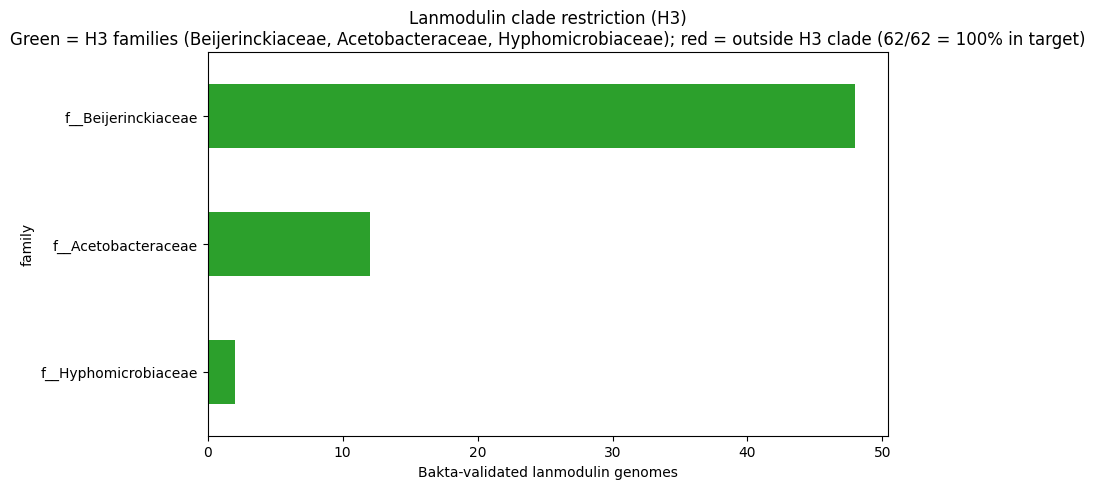

In [8]:
family_counts = lanm_with_tax["family"].value_counts()
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#2ca02c" if f in H3_FAMILIES else "#d62728" for f in family_counts.index]
family_counts.plot(kind="barh", ax=ax, color=colors)
ax.invert_yaxis()
ax.set_xlabel("Bakta-validated lanmodulin genomes")
ax.set_title(
    f"Lanmodulin clade restriction (H3)\n"
    f"Green = H3 families (Beijerinckiaceae, Acetobacteraceae, Hyphomicrobiaceae); "
    f"red = outside H3 clade ({n_in}/{n_total} = {n_in/n_total:.0%} in target)"
)
plt.tight_layout()
plt.savefig(FIG / "h3_lanmodulin_clade_restriction.png", dpi=150)
plt.show()


## 6. Summary

NB05 has formally tested H3 against the 80% thresholds for both clade restriction and xoxF co-occurrence. The verdict is reported in `data/h3_lanmodulin_clade_restriction.csv` for inclusion in REPORT.md.

NB06 turns to the REE-AMD MAG case study (n=37).